In [14]:
from cifar import CIFAR10
from PIL import Image
from typing import Union
import jittor as jt
from jittor import nn
from jittor.dataset import Dataset
from jittor.models import resnet18
from jittor import transform
import numpy as np
from itertools import permutations
from math import factorial
import os

jt.flags.use_cuda = 1
jt.flags.use_tensorcore = 1
np.random.seed(114)
jt.misc.set_global_seed(514)

# original_set = CIFAR10(root='data/', train=True, download=False, resize=(64, 64))
# original_set = [original_set[i][0] for i in range(len(original_set))]  # a list containing all 50000 PIL images
# # original_set[0].show()
# print(type(original_set[0]))
# print(np.array(original_set[0]).shape)
# print(len(original_set))
#
# original_test = CIFAR10(root='data/', train=False, download=False)
# original_test = [original_test[i][0] for i in range(len(original_test))]
# print(len(original_test))

<class 'PIL.Image.Image'>
(64, 64, 3)
50000
10000


In [15]:
def jigsaw_cutter(img: Image, cuts: int, shape=None, resize_shape=None):
    if shape is None:
        shape = img.size
    assert shape[0] % cuts == 0 and shape[1] % cuts == 0
    imgs = []
    stepx, stepy = shape[0] // cuts, shape[1] // cuts
    for i in range(cuts):
        for j in range(cuts):
            if resize_shape is None:
                imgs.append(img.crop((j * stepx, i * stepy, (j + 1) * stepx, (i + 1) * stepy)))
            else:
                imgs.append(img.crop((j * stepx, i * stepy, (j + 1) * stepx, (i + 1) * stepy)).resize(resize_shape))
    return imgs, range(cuts ** 2)


def jigsaw_shuffle(imgs: list[Image], seq: list[int], order=None):
    if order is None:
        sseq = np.arange(len(seq))
        np.random.shuffle(sseq)
        sseq = sseq.tolist()
    else:
        sseq = order
    return [imgs[indice] for indice in sseq], [seq[indice] for indice in sseq]


def jigsaw_shuffle_all(dataset, cuts=2, resize_shape=None, with_original=True):
    shuffle_all = []
    for oda in dataset:
        cutted = jigsaw_cutter(oda, cuts, resize_shape=resize_shape)
        if with_original:
            for per in permutations(np.arange(cuts ** 2)):
                shuffle_all.append(jigsaw_shuffle(*cutted, per))
        else:
            for per in permutations(np.arange(cuts ** 2)):
                if (per == np.arange(cuts ** 2)).all():
                    continue
                shuffle_all.append(jigsaw_shuffle(*cutted, per))
    return shuffle_all


def jigsaw_filler(imgs: list[Image], seq: list[int], padding: int = 1, shape=None, save_path: str = None, silent: bool = True):
    assert shape is not None or int(len(seq) ** 0.5) ** 2 == len(seq)  # must determine shape if not cut as square
    cuts = int(len(seq) ** 0.5)
    size = imgs[0].size
    if shape is None:
        shape = (cuts * size[0] + (cuts - 1) * padding, cuts * size[0] + (cuts - 1) * padding)
    canvas = Image.new("RGB", shape, color=(255, 255, 255))
    for i in range(len(seq)):
        canvas.paste(imgs[i], ((seq[i] % cuts) * (size[1] + padding), (seq[i] // cuts) * (size[0] + padding), (seq[i] % cuts) * (size[1] + padding) + size[1], (seq[i] // cuts) * (size[0] + padding) + size[0]))
    if not silent:
        canvas.show()
    if save_path is not None:
        save_path += 'filled' if save_path[-1] in ['/', '\\'] else ''
        save_path += '.png' if '.png' not in save_path else ''
        canvas.save(save_path)
    return canvas


def block_upsize(imgs: list[Image], cuts=2, resize_shape=None):
    if resize_shape is not None:
        for i in range(len(imgs)):
            imgs[i] = jigsaw_filler(*jigsaw_cutter(imgs[i], cuts=cuts, resize_shape=resize_shape), padding=0)
    return imgs


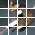

In [67]:
# jigsaw_filler(*jigsaw_cutter(original_set[1], 2), save_path='pics/tmp11')
# jigsaw_filler(*jigsaw_shuffle(*jigsaw_cutter(original_set[1], 2)), save_path='pics/tmp12')
# jigsaw_filler(jigsaw_shuffle(*jigsaw_cutter(original_set[1], 2))[0], list(range(4)), save_path='pics/tmp13')
# print(np.array(jigsaw_cutter(original_set[1], 4)[0][0]).shape)

In [8]:
class JigsawPuzzle(Dataset):
    def __init__(self, raw, data, cuts=2, batch_size=32, shuffle=True):
        super().__init__(batch_size=batch_size, shuffle=shuffle)
        self.raw = raw
        self.data = data
        self.repeat = factorial(cuts ** 2)
        self.total = len(self.raw)
        self.cuts = int(len(data[0][0]) ** 0.5)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        original_images = jt.array(transform.to_tensor(self.raw[idx // self.repeat]))
        shuffled_images = jt.array(transform.to_tensor(jigsaw_filler(*self.data[idx // self.repeat], padding=0)))
        image_pieces = jt.array([transform.to_tensor(self.data[idx][0][i]) for i in range(self.cuts ** 2)])
        label_sequence = jt.array(self.data[idx][1])
        return original_images, shuffled_images, image_pieces, label_sequence  # original image, shuffled image, pieces, label sequence


def get_dataset(cuts, batch_size=32, shuffle=True, resize_shape=None, resize_piece=None, amount=None, with_original=True):
    original_set = CIFAR10(root='data/', train=True, download=False, resize=resize_shape)
    original_set = [original_set[i][0] for i in range(len(original_set))][:amount]  # a list containing all 50000 PIL images
    original_test = CIFAR10(root='data/', train=False, download=False, resize=resize_shape)
    original_test = [original_test[i][0] for i in range(len(original_test))]
    # if resize_shape is not None:
    #     original_set = [original_set[i].resize(resize_shape) for i in range(len(original_set))]
    #     original_test = [original_test[i].resize(resize_shape) for i in range(len(original_test))]
    train_loader = JigsawPuzzle(block_upsize(original_set, cuts=cuts, resize_shape=resize_piece), jigsaw_shuffle_all(original_set, cuts=cuts, resize_shape=resize_piece, with_original=with_original), cuts, batch_size, shuffle)
    test_loader = JigsawPuzzle(block_upsize(original_test, cuts=cuts, resize_shape=resize_piece), jigsaw_shuffle_all(original_test, cuts=cuts, resize_shape=resize_piece, with_original=with_original), cuts, batch_size, shuffle)
    return train_loader, test_loader

In [9]:
# for original, shuffled, traind, labeld in get_dataset(2, batch_size=500)[0]:
#     print(original.shape, shuffled.shape, traind.shape, labeld.shape)
# print(np.array(get_dataset(2)[0][1][1]).shape)

In [10]:
current_size = 16

In [11]:
class Discriminator(nn.Module):
    def __init__(self, shape: Union[tuple, int] = (32, 32)):
        super().__init__()
        if type(shape) is int:
            shape = (shape, shape)
        self.conv1 = nn.Conv2d(3, 8, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, stride=1, padding=1)
        self.linear1 = nn.Linear(16 * shape[0] * shape[1], 4096)
        self.linear2 = nn.Linear(4096, 1)
        self.relu = nn.Relu()

    def execute(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view((x.shape[0], -1))
        x = self.relu(self.linear1(x))
        x = self.linear2(x)
        with open('logDis.txt', 'a') as f:
            f.writelines(str(x.view(-1)))
            f.writelines('\n')
        return x


class Classifier(nn.Module):
    def __init__(self, P, cut: int = 2, shape: Union[tuple, int] = (16, 16)):
        super().__init__()
        if type(shape) is int:
            shape = (shape, shape)
        self.conv1 = nn.Conv2d(32 + 3 * cut ** 2, 32, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=1, padding=1)
        self.linear1 = nn.Linear(64 * shape[0] * shape[1], 4096)
        self.linear2 = nn.Linear(4096, P)
        self.relu = nn.Relu()

    def execute(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view((x.shape[0], -1))
        x = self.relu(self.linear1(x))
        x = self.linear2(x)
        with open('logclass.txt', 'a') as f:
            f.writelines(str(x.view(-1)))
            f.writelines('\n')
        return x


class Encoder(nn.Module):
    def __init__(self, cut: int = 2, with_raw=True, shape: Union[tuple, int] = (32, 32)):
        super().__init__()
        self.with_raw = with_raw
        self.conv0 = nn.Conv2d(3, 3 * cut ** 2, 5, stride=1, padding=2)
        self.conv1 = nn.Conv2d(3 * cut ** 2, 32, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=1, padding=1)
        self.linear1 = nn.Linear(64 * shape[0] * shape[1], 2048)
        self.linear2 = nn.Linear(2048, 512)
        self.classify = nn.Linear(512, 10)
        self.relu = nn.Relu()

    def execute(self, x, get_features=True):
        raw = None
        if self.with_raw:
            raw = x
        if not get_features:
            x = self.relu(self.conv0(x))
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        # with open('logencode.txt', 'a') as f:
        #     f.writelines(str(x.view(-1)))
        #     f.writelines('\n')
        if get_features:
            if self.with_raw:
                x = jt.concat([raw, x], dim=1)
            return x
        x = self.relu(self.linear1(x.view((x.shape[0], -1))))
        x = self.relu(self.linear2(x))
        x = self.classify(x)
        return x

    # transfun = transform.Compose([
    #     transform.Resize((224, 224)),
    #     transform.ToTensor(),
    #     transform.ImageNormalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    # ])
    #
    # backbone = resnet18(pretrained=True)
    # # print(list(backbone.children()))
    # modules = list(backbone.children())[:-2]
    # backbone = jt.nn.Sequential(*modules)

In [12]:
def zero_or_one(arr):
    zoo = []
    for _i in range(len(arr)):
        zoo.append(1 if arr[_i][0] > 0.5 else 0)
    return jt.array(zoo, dtype=jt.int32)


def max_to_one(arr):
    max_value = jt.max(arr)
    arr[arr != max_value] = 0
    arr[arr == max_value] = 1
    return jt.int32(arr)


In [13]:
train_loader, test_loader = get_dataset(2, batch_size=50, resize_piece=(current_size, current_size), with_original=False)

In [14]:
import os
from animation import spinning_stick as rolling_ball

if not os.path.exists('class.pkl'):

    discriminator = Discriminator(shape=(current_size * 2, current_size * 2))

    criterion = nn.MSELoss()
    optimizer_discriminator = nn.SGD(discriminator.parameters(), lr=0.01, weight_decay=0.001)
    lr_scheduler_discriminator = jt.lr_scheduler.StepLR(optimizer_discriminator, step_size=2000, gamma=0.631)
    num_epochs = 3
    true_label = jt.ones(1, train_loader.batch_size)
    false_label = jt.zeros(1, train_loader.batch_size)
    for epoch in range(num_epochs):
        for original, shuffled, _, _ in train_loader:
            pred_true = discriminator(original)
            pred_false = discriminator(shuffled)
            loss = criterion(pred_true, true_label) + criterion(pred_false, false_label)
            rolling_ball(7, 0, f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Lr: {optimizer_discriminator.lr}")
            print()
            optimizer_discriminator.__setattr__('lr', optimizer_discriminator.lr)
            # optimizer_encoder.__setattr__('lr', optimizer_model.lr)
            optimizer_discriminator.zero_grad()
            optimizer_discriminator.backward(loss)
            optimizer_discriminator.step()
            # optimizer_encoder.zero_grad()
            # optimizer_encoder.backward(loss)
            # optimizer_encoder.step()
            optimizer_discriminator.step()
    discriminator.save('class.pkl')
acc = 0
for original, shuffled, _, _ in test_loader:
    # print(original.shape, shuffled.shape, train_data.shape, train_seq.shape)
    # pred_seq = model(train_data.view(train_data.shape[0], -1, 16, 16))
    pred_true = zero_or_one(discriminator(original))
    acc += jt.sum(pred_true)
    pred_false = zero_or_one(discriminator(shuffled))
    acc += jt.sum(1 - pred_false)
    print(pred_true, pred_false)
print(acc / len(test_loader), acc)

In [11]:
import os

if not os.path.exists('encoder.pkl'):
    from animation import rolling_ball

    cifar10 = CIFAR10(root='data/', train=True, download=False, resize=(current_size * 2, current_size * 2))
    encoder = Encoder(shape=(current_size * 2, current_size * 2))

    criterion = nn.MSELoss()
    optimizer_encoder = nn.SGD(encoder.parameters(), lr=0.01, weight_decay=0.001)
    lr_scheduler_encoder = jt.lr_scheduler.StepLR(optimizer_encoder, step_size=15, gamma=0.1)
    num_epochs = 1
    for epoch in range(num_epochs):
        for train_data, train_label in cifar10:
            # print(train_data.shape, train_label.shape)
            x = train_data.transpose(0, 3, 1, 2) / 255
            x = jt.float32(x)
            pred_label = encoder(x, False)
            y = nn.one_hot(train_label, num_classes=10)
            loss = criterion(pred_label, y)
            rolling_ball(7, 0, f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Lr: {optimizer_encoder.lr}")
            optimizer_encoder.__setattr__('lr', optimizer_encoder.lr)
            # optimizer_encoder.__setattr__('lr', optimizer_model.lr)
            optimizer_encoder.zero_grad()
            optimizer_encoder.backward(loss)
            optimizer_encoder.step()
            # optimizer_encoder.zero_grad()
            # optimizer_encoder.backward(loss)
            # optimizer_encoder.step()
        lr_scheduler_encoder.step()
        if (epoch + 1) % 5 == 0:
            cifar10test = CIFAR10(root='data/', train=False, download=False, resize=(current_size * 2, current_size * 2))
            acc = 0
            for train_data, train_label in cifar10test:
                x = train_data.transpose(0, 3, 1, 2) / 255
                x = jt.float32(x)
                pred_label = encoder(x, False)
                y = nn.one_hot(train_label, num_classes=10)
                for v in range(len(y)):
                    acc += np.sum(np.abs(max_to_one(pred_label[v]) - y[v])) / 2
                    # print(max_to_one(pred_label[v]) , y[v])
            print('\n', 1 - acc / 10000)
    encoder.save('encoder.pkl')

In [12]:
if os.path.exists('encoder.pkl'):
    encoder = Encoder(shape=(current_size * 2, current_size * 2))
    encoder.load('encoder.pkl')

In [13]:
acc = 0
cifar10 = CIFAR10(root='data/', train=True, download=False, resize=(current_size * 2, current_size * 2))
for train_data, train_label in cifar10:
    x = train_data.transpose(0, 3, 1, 2) / 255
    x = jt.float32(x)
    pred_label = encoder(x, False)
    y = nn.one_hot(train_label, num_classes=10)
    for v in range(len(y)):
        acc += np.sum(np.abs(max_to_one(pred_label[v]) - y[v])) / 2
        # print(max_to_one(pred_label[v]) , y[v])
print(1 - acc / 50000)

cifar10test = CIFAR10(root='data/', train=False, download=False, resize=(current_size * 2, current_size * 2))
acc = 0
for train_data, train_label in cifar10test:
    x = train_data.transpose(0, 3, 1, 2) / 255
    x = jt.float32(x)
    pred_label = encoder(x, False)
    y = nn.one_hot(train_label, num_classes=10)
    for v in range(len(y)):
        acc += np.sum(np.abs(max_to_one(pred_label[v]) - y[v])) / 2
        # print(max_to_one(pred_label[v]) , y[v])
print(1 - acc / 10000)

0.44667999999999997
0.4454


In [3]:
# encodel = Encoder()
# data = None
#
# for _, _, i, j in get_dataset(2)[0]:
#     print(np.array(i).shape, np.array(j).shape)
#     data = i.reshape(i.shape[0], -1, *i.shape[-2:])
#     break
#
# features = encodel(data)
# print(features.shape)
# feature1 = features[0][0]
# print(feature1.shape)
# Image.fromarray((255 * feature1.numpy()).astype(np.uint8)).save(f'output/test_feature.png', save_all=True)
#
# cladel = Classifier(1000)
# result = cladel(features)
# print(result.shape)

In [15]:
class JigsawSolver(nn.Module):
    def __init__(self, cut: int = 2, shape: Union[tuple, int] = (16, 16)):
        super().__init__()
        if type(shape) is int:
            shape = (shape, shape)
        self.conv1 = nn.Conv2d(64 + 3 * cut ** 2, 64, 3, stride=1, padding=1)
        # self.conv1 = nn.Conv2d(3 * cut ** 2, 64, 5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(64, 64, 3, stride=1, padding=1)
        self.linear1 = nn.Linear(64 * shape[0] * shape[1], 4096)
        self.linear2 = nn.Linear(4096, cut ** 2)
        self.relu = nn.Relu()

    def execute(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view((x.shape[0], -1))
        x = self.relu(self.linear1(x))
        x = self.linear2(x)
        with open('logclass.txt', 'a') as f:
            f.writelines(str(x.view(-1)))
            f.writelines('\n')
        return x

In [16]:
train_loader, test_loader = get_dataset(2, batch_size=20, resize_piece=(current_size, current_size))
# model = JigsawSolver(shape=(current_size, current_size))
# model.load('model.pkl')

In [17]:
def rank(lst: jt.array):
    arr = lst.numpy()
    sorted_indices = np.argsort(arr, axis=1)
    ranks = np.empty_like(sorted_indices)
    ranks[np.arange(len(lst))[:, np.newaxis], sorted_indices] = np.arange(arr.shape[1])
    return ranks


def transrank(lst: jt.array):
    return 1 / (lst + 1)


def remap(imgs, transarray, with_gradient=False):
    assert imgs[0].shape[-1] == imgs[0].shape[-2]  # should be square
    batch, cuts, _, shape, _ = imgs.shape  # batch, cuts**2, 3, H, W
    cuts = int(np.sqrt(cuts))
    canvas = jt.zeros((batch, 3, shape * cuts, shape * cuts))
    trans = rank(transarray)
    for i in range(batch):
        for j in range(cuts ** 2):
            _x = trans[i][j] % cuts
            _y = trans[i][j] // cuts
            if with_gradient:
                canvas[i, :, _x * shape:(_x + 1) * shape, _y * shape:(_y + 1) * shape] = imgs[i, j, :, :, :] * 1e5 * transarray[i][j] / (1e5 + transarray[i][j].detach())
            else:
                canvas[i, :, _x * shape:(_x + 1) * shape, _y * shape:(_y + 1) * shape] = imgs[i, j, :, :, :]
    return canvas


def edge_loss(maps: jt.array, cuts):
    assert cuts in [2, 4]  # No implementation
    _loss = jt.array(0, dtype=jt.float32)
    _, _, shape, _ = maps.shape
    if cuts == 2:
        mid = shape // 2
        for i in maps:
            _loss += jt.mean(jt.abs(i[:, mid - 1, :] - i[:, mid, :])) + jt.mean(jt.abs(i[:, :, mid - 1] - i[:, :, mid]))
    elif cuts == 4:
        pass
    return _loss

# for original, shuffled, train_data, train_seq in train_loader:
#     print(original.shape, shuffled.shape, train_data.shape, train_seq.shape)
#     # pred_seq = model(train_data.view(train_data.shape[0], -1, 16, 16))
#     pred_seq = model(encoder(train_data.view(train_data.shape[0], -1, current_size, current_size)))
#     print(pred_seq.requires_grad)
#     print(remap(train_data, pred_seq, True).shape)
#
#     break

In [50]:
from animation import rolling_ball

model = JigsawSolver(shape=(current_size, current_size))
encoder = Encoder(shape=(current_size * 2, current_size * 2))

criterion = nn.L1Loss()
# optimizer_encoder = nn.Adam(encoder.parameters(), lr=0.001)
optimizer_model = nn.SGD(model.parameters(), lr=0.1)
lr_scheduler_model = jt.lr_scheduler.StepLR(optimizer_model, step_size=10000, gamma=0.316, last_epoch=7)
num_epochs = 3
for epoch in range(num_epochs):
    for original, shuffled, train_data, train_seq in train_loader:
        # print(original.shape, shuffled.shape, train_data.shape, train_seq.shape)
        # pred_seq = model(train_data.view(train_data.shape[0], -1, 32, 32))
        pred_seq = model(encoder(train_data.view(train_data.shape[0], -1, current_size, current_size)))
        # print(criterion(pred_seq, train_seq), edge_loss(remap(train_data, pred_seq, with_gradient=True), cuts=2)* 1e-3)
        loss = criterion(pred_seq, train_seq) + edge_loss(remap(train_data, pred_seq, with_gradient=True), cuts=2) * 1e-3
        rolling_ball(7, 0, f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Lr: {optimizer_model.lr}, {criterion(pred_seq, train_seq)}  {edge_loss(remap(train_data, pred_seq, with_gradient=True), cuts=2) * 1e-3}")

        optimizer_model.__setattr__('lr', optimizer_model.lr)
        # optimizer_encoder.__setattr__('lr', optimizer_model.lr)
        optimizer_model.zero_grad()
        optimizer_model.backward(loss)
        optimizer_model.step()
        # optimizer_encoder.zero_grad()
        # optimizer_encoder.backward(loss)
        # optimizer_encoder.step()
        lr_scheduler_model.step()
model.save('model.pkl')

(  ●    )Epoch [1/3], Loss: 0.9891, Lr: 0.1, 0.9842681288719177  0.0047869649715721615

KeyboardInterrupt: 

In [ ]:
total_acc = 0
for original, shuffled, test_data, test_seq in test_loader:
    # print(original.shape, shuffled.shape)
    # pred_seq = model(test_data.view(test_data.shape[0], -1, 32, 32))
    pred_seq = model(encoder(test_data.view(test_data.shape[0], -1, current_size, current_size)))
    r = rank(pred_seq)
    test_acc = 0
    for i in range(len(r)):
        # print(r[i], np.array(test_seq[i]), np.sum(r[i] == np.array(test_seq[i])))
        test_acc += np.sum(r[i] == np.array(test_seq[i]))
    total_acc += test_acc
    print(test_acc / len(r) / 4, test_acc)
    # break
print('test accuracy: {:.4f}'.format(total_acc / len(test_loader) / 4))

# total_acc = 0
# for original, shuffled, test_data, test_seq in train_loader:
#     # print(original.shape, shuffled.shape)
#     # pred_seq = model(test_data.view(test_data.shape[0], -1, 16, 16))
#     pred_seq = model(encoder(test_data.view(test_data.shape[0], -1, current_size, current_size)))
#     r = rank(pred_seq)
#     test_acc = 0
#     for i in range(len(r)):
#         # print(r[i], np.array(test_seq[i]), np.sum(r[i] == np.array(test_seq[i])))
#         test_acc += np.sum(r[i] == np.array(test_seq[i]))
#     total_acc += test_acc
#     # print(test_acc / len(r) / 4, test_acc)
#     # break
# print('test accuracy: {:.4f}'.format(total_acc / len(train_loader) / 4))

In [ ]:
with open('RESULT.txt', 'a') as f:
    f.writelines('test accuracy: {:.4f}'.format(total_acc / len(test_loader) / 4))
    f.writelines('\n')

In [27]:
def tv_loss2(img):
    img = np.array(img, dtype=np.float32)
    half = int(img.shape[0] / 2), int(img.shape[1] / 2)
    tv_h = np.sum(np.abs(img[half[0] - 1, :, :] - img[half[0], :, :]))
    tv_w = np.sum(np.abs(img[:, half[1] - 1, :] - img[:, half[1], :]))
    return tv_h + tv_w


def simple_solver(imgs: list[Image]):
    cuts = int(len(imgs) ** 0.5)
    all_res = []
    for per in permutations(np.arange(cuts ** 2)):
        all_res.append(tv_loss2(jigsaw_filler(imgs, per, padding=0)))
    return jt.array(list(permutations(np.arange(cuts ** 2)))[all_res.index(min(all_res))])

In [29]:
# x = get_dataset(2)[1][123]
# print(x[3])
# y = [Image.fromarray((255 * x[2][i].transpose((1, 2, 0)).numpy()).astype(np.uint8)) for i in range(4)]
# print(simple_solver(y))
acc = 0
data1, data2 = get_dataset(2, shuffle=False, resize_piece=(64, 64))
for i in range(len(data1) // 24):
    x = data1[24 * i]
    y = x[3]
    z = [Image.fromarray((255 * x[2][j].transpose((1, 2, 0)).numpy()).astype(np.uint8)) for j in range(4)]
    a = simple_solver(z)
    # print(a, y)
    if jt.max(jt.abs(a - y)) == 0:
        acc = acc + 1
print(acc / len(data1) * 24, acc)

acc = 0
for i in range(len(data2) // 24):
    x = data2[24 * i]
    y = x[3]
    z = [Image.fromarray((255 * x[2][j].transpose((1, 2, 0)).numpy()).astype(np.uint8)) for j in range(4)]
    a = simple_solver(z)
    # print(a, y)
    if jt.max(jt.abs(a - y)) == 0 == 0:
        acc = acc + 1
print(acc / len(data2) * 24, acc)

0.82102 41051
0.8219000000000001 8219


In [13]:
from jittor import nn
class Empty(nn.Module):
    def __init__(self):
        super().__init__()
a = Empty()
a.save('a.pkl')